In [2]:
import os
# os.walk() goes through every folder and file inside '/kaggle/input'
# dirname = current folder being looked at, filenames = list of files in it
dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # os.path.join builds the full file path correctly (handles the '/' for you)
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.endswith('.csv'):
            dataset_paths.append(full_path)

# If nothing printed above: click 'Add Input' (top-right) and attach the
# Spotify Tracks Dataset before running the next cells.

/kaggle/input/datasets/gangabhavanidasam/student-performance-factor-dataset/StudentPerformanceFactors.csv


In [3]:
import numpy as np              # numerical arrays & math -> aliased as 'np' by convention
import pandas as pd             # tabular data (DataFrames) -> aliased as 'pd' by convention
import matplotlib.pyplot as plt # base plotting -> 'plt' is the standard alias
import seaborn as sns           # statistical plots built on matplotlib -> 'sns' is the standard alias
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
# StandardScaler   -> for standardization (mean=0, std=1)
# MinMaxScaler     -> for normalization (squashes values into [0,1])
# LabelEncoder     -> converts category text into integer codes

sns.set_style('whitegrid')  # cosmetic: gives every seaborn plot a light grid background, easier to read values

print('NumPy version:', np.__version__)   # confirms the library actually imported and shows its version
print('Pandas version:', pd.__version__)

NumPy version: 2.0.2
Pandas version: 2.3.3


## Loading the real dataset — Pandas Series & DataFrame

A **Series** is a single labeled column of data. A **DataFrame** is a full table made of multiple Series — this is what `pd.read_csv()` gives you.

Replace the path below with the exact path printed by the Kaggle input cell above if it differs.

In [4]:
# Check whether a CSV dataset is attached
assert len(dataset_paths) > 0, "No CSV found under /kaggle/input - click 'Add Input' and attach the Student Performance dataset."

# Load the CSV file
df = pd.read_csv(dataset_paths[0])

# Some CSV files may contain an extra unnamed index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Check number of rows and columns
df.shape

(6607, 20)

In [5]:
# .head() shows the first 5 rows by default - a quick visual check of what the data looks like
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
# A single column pulled out of a DataFrame is a Series
gender_series = df['Gender']

print(type(gender_series))   # confirms it's a pandas Series, not a DataFrame

gender_series.head()

<class 'pandas.core.series.Series'>


0      Male
1    Female
2      Male
3      Male
4    Female
Name: Gender, dtype: object

## Data types: Structured vs Unstructured, Features vs Target

Structured data = rows and columns lo neatly organized data.
Example: mana Student Performance dataset — each row represents a student, and columns contain information like Hours_Studied, Attendance, Gender, Exam_Score, etc.

Unstructured data = fixed rows and columns format lo undani raw data.
Examples: images, audio, videos, raw text.

Features vs Target
Features = model ki input ga icche columns.
Hours_Studied
Attendance
Sleep_Hours
Previous_Scores
Target = model predict cheyyalsina column.
Example: Exam_Score

In [9]:
# .info() shows every column's name, non-null count, and data type in one shot
# This is how you spot which columns are numeric (structured, ready for math) vs text/object (need encoding later)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [10]:
# .describe() gives summary statistics (count, mean, std, min, quartiles, max) for every NUMERIC column only
# This is your first real look at the shape and spread of the structured, numeric part of the data
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


 ## Pandas — loc/iloc, filtering, groupby, merge/join

- **`loc`** — select rows/columns by their LABEL (name).
- **`iloc`** — select rows/columns by their integer POSITION (like list indexing).
- **Filtering** — keep only rows matching a condition.
- **`groupby`** — split data into groups, then apply an aggregation to each group.
- **`merge`/`join`** — combine two DataFrames together, like a SQL join.

In [11]:
# .loc[row_label, column_label] -> select by LABEL
# Here: rows 0 to 2 (inclusive), only the 'Gender' and 'Exam_Score' columns
df.loc[0:2, ['Gender', 'Exam_Score']]

,Gender,Exam_Score
0,Male,67
1,Female,61
2,Male,74


In [12]:
# .iloc[row_position, column_position] -> select by POSITION (integers only)
# Here: first 3 rows, first 4 columns, regardless of their names
df.iloc[0:3, 0:4]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources
0,23,84,Low,High
1,19,64,Low,Medium
2,24,98,Medium,Medium


In [13]:
# FILTERING: a condition inside df[...] returns only rows where that condition is True

# Students whose Exam_Score is greater than 80
high_score_students = df[df['Exam_Score'] > 80]
print('Students with Exam_Score > 80:', high_score_students.shape[0])

# Combine multiple conditions using & (AND)
# Students with Attendance > 80 AND Exam_Score > 80
good_students = df[
    (df['Attendance'] > 80) & 
    (df['Exam_Score'] > 80)
]

print('Students with good attendance AND high exam score:', good_students.shape[0])

Students with Exam_Score > 80: 43
Students with good attendance AND high exam score: 20


In [14]:
# GROUPBY: split rows into groups by a column's value, then aggregate each group

# Group all students by 'Gender', calculate the mean 'Exam_Score',
# and sort so the highest average score appears first
gender_avg_score = df.groupby('Gender')['Exam_Score'].mean().sort_values(ascending=False)

gender_avg_score

Gender
Female    67.244898
Male      67.228894
Name: Exam_Score, dtype: float64

In [15]:
# MERGE / JOIN demo
# Our dataset is a single table, so we create a small example DataFrame

gender_lookup = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Gender_Group': ['M', 'F']
})

# how='left' keeps every row from df
# and adds matching Gender_Group information
merged_sample = df.head(10).merge(
    gender_lookup,
    on='Gender',
    how='left'
)

merged_sample[['Gender', 'Gender_Group']]

,Gender,Gender_Group
0,Male,M
1,Female,F
2,Male,M
3,Male,M
4,Female,F
5,Male,M
6,Male,M
7,Male,M
8,Male,M
9,Male,M


 ## Visualization — why it matters before we even touch preprocessing

Numbers alone can hide problems. A histogram, box plot, or heatmap can show a skew, an outlier, or a relationship that a table of numbers never reveals at a glance. This is why EDA (Exploratory Data Analysis) always comes with plots, not just `.describe()`.

###  Matplotlib — line, scatter, bar, histogram, subplots

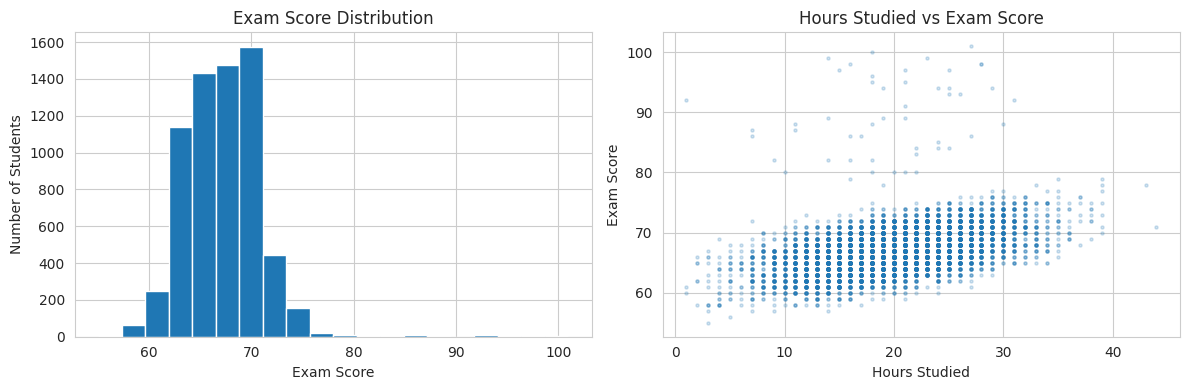

In [16]:
# subplots(1, 2) creates a figure with 1 row and 2 columns of plots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# HISTOGRAM: shows the distribution of a single numeric column
axes[0].hist(df['Exam_Score'], bins=20)
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Number of Students')

# SCATTER PLOT: shows the relationship between two numeric columns
# One dot represents one student
axes[1].scatter(df['Hours_Studied'], df['Exam_Score'], alpha=0.2, s=5)
axes[1].set_title('Hours Studied vs Exam Score')
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

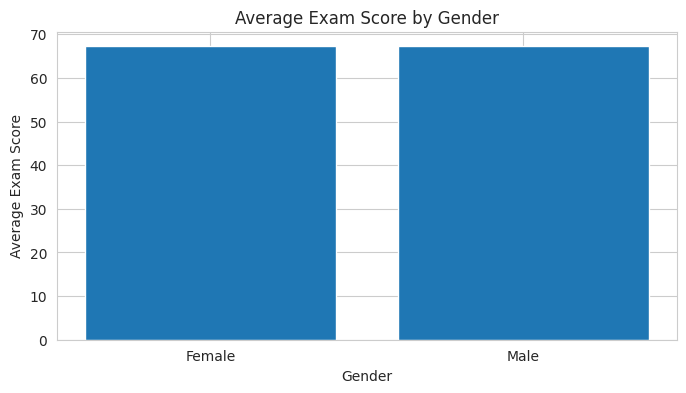

In [17]:
# BAR CHART: compares a value across categories
# Here, average Exam_Score for each gender

gender_avg_score = df.groupby('Gender')['Exam_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(gender_avg_score.index, gender_avg_score.values)

plt.title('Average Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Exam Score')
plt.show()

### Seaborn — distribution, box, pair plots, correlation heatmap

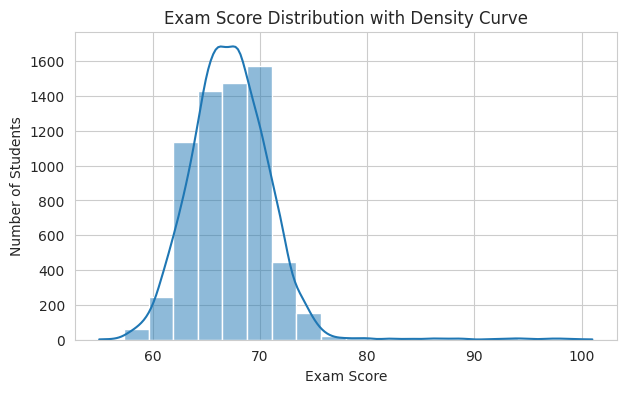

In [18]:
# sns.histplot with kde=True overlays a smooth density curve
# on top of the histogram bars

plt.figure(figsize=(7, 4))

sns.histplot(
    df['Exam_Score'],
    bins=20,
    kde=True
)

plt.title('Exam Score Distribution with Density Curve')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')

plt.show()

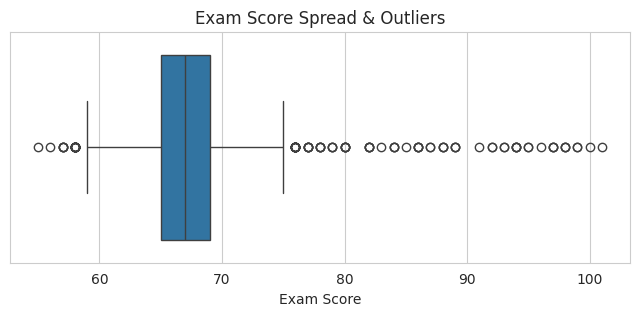

In [19]:
# BOX PLOT: shows median, quartiles, and OUTLIERS
# (dots beyond the whiskers) at a glance

plt.figure(figsize=(8, 3))

sns.boxplot(x=df['Exam_Score'])

plt.title('Exam Score Spread & Outliers')
plt.xlabel('Exam Score')

plt.show()

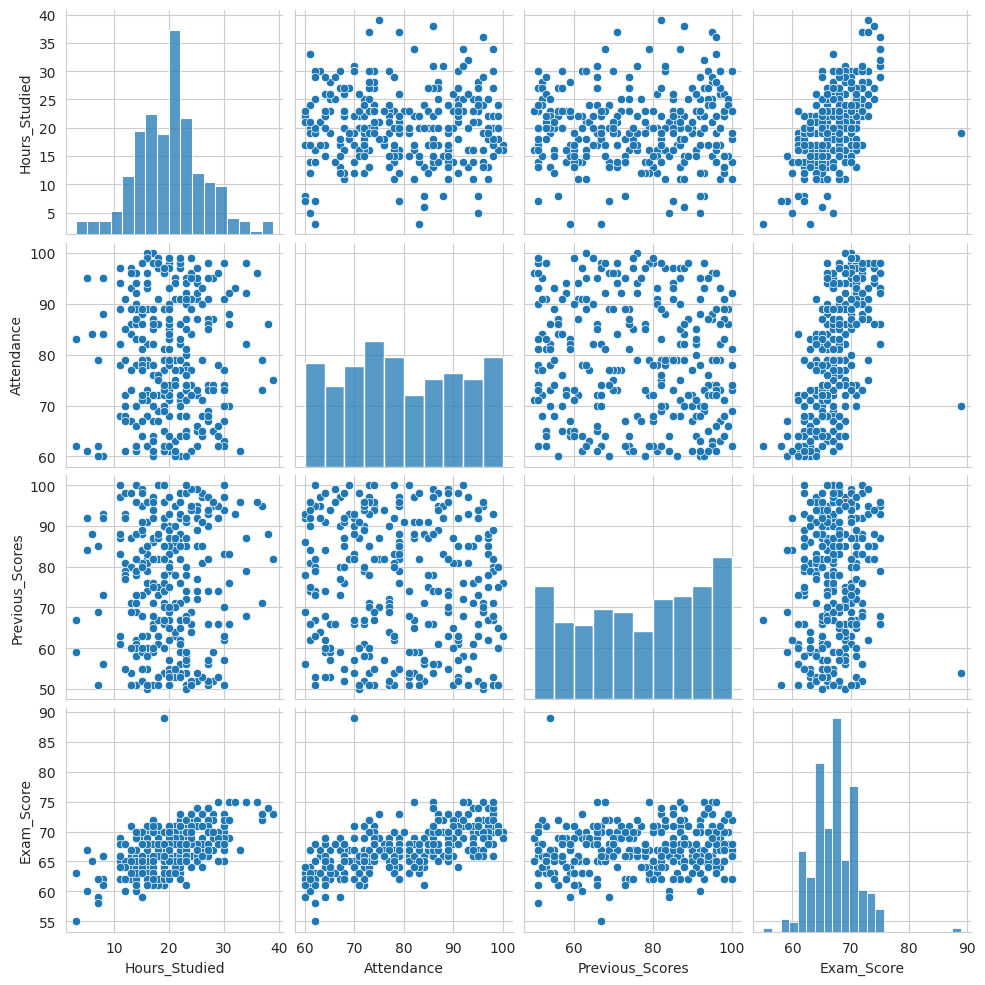

In [20]:
# PAIR PLOT: plots every numeric column against every other numeric column
# Useful to spot relationships across many columns at once

subset_cols = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Exam_Score'
]

sns.pairplot(
    df[subset_cols].sample(300, random_state=42)
)

plt.show()

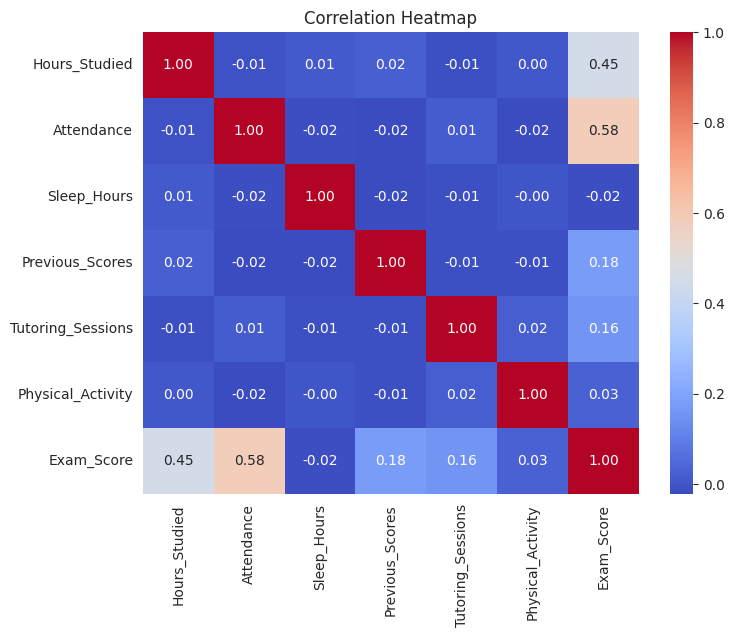

In [21]:
# CORRELATION HEATMAP: shows how strongly numeric columns
# relate to every other numeric column
# .corr() computes correlation coefficients (-1 to 1)
# annot=True prints the actual number in each cell

numeric_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity',
    'Exam_Score'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## EDA — reading what the plots just told us

Quick checklist we apply to every dataset:

Distributions — is a column skewed, normal, or spread flat? (see the Exam Score histogram above)
Relationships — do two columns move together? (see the Hours Studied vs Exam Score scatter plot, and the pairplot)
Correlation — is there a strong numeric relationship worth noting? (see the heatmap — values close to +1 or -1 are strong)
Spotting issues — outliers (box plot dots), skew (long histogram tail), or unexpected gaps

We'll now act on what EDA revealed: missing values, duplicates, and outliers need to be checked and handled before this data can go into any model.

## Data preprocessing — missing values, duplicates, outliers, cleaning

In [22]:
# .isnull() marks every cell True/False for missing, .sum() adds those up per column
# sort_values shows the columns with the MOST missing data first
df.isnull().sum().sort_values(ascending=False).head(10)

Parental_Education_Level      90
Teacher_Quality               78
Distance_from_Home            67
Hours_Studied                  0
Access_to_Resources            0
Parental_Involvement           0
Attendance                     0
Extracurricular_Activities     0
Motivation_Level               0
Internet_Access                0
dtype: int64

In [23]:
# dropna(subset=[...]) removes only rows that have missing values
# in the listed columns

# We use these columns because they are important for our analysis/model
df = df.dropna(
    subset=['Hours_Studied', 'Attendance', 'Exam_Score']
)

print(
    'Remaining missing values across all columns:',
    df.isnull().sum().sum()
)

Remaining missing values across all columns: 235


In [24]:
# .duplicated() flags rows that are exact copies of an earlier row
print('Duplicate rows found:', df.duplicated().sum())

# drop_duplicates() removes them, keeping the first occurrence by default
df = df.drop_duplicates()

# reset_index(drop=True) renumbers rows 0,1,2,... cleanly after rows were removed above
# (without this, row numbers would have gaps where dropped rows used to be)
df = df.reset_index(drop=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (6607, 20)


In [25]:
# OUTLIER DETECTION using the IQR (Interquartile Range) method

Q1 = df['Exam_Score'].quantile(0.25)   # value below which 25% of the data falls
Q3 = df['Exam_Score'].quantile(0.75)   # value below which 75% of the data falls
IQR = Q3 - Q1                          # middle 50% spread of the data

# Anything beyond 1.5 × IQR past Q1/Q3 is treated as a statistical outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Exam_Score'] < lower_bound) |
    (df['Exam_Score'] > upper_bound)
]

print(
    f'Exam Score outliers: {outliers.shape[0]} rows '
    f'(normal range: {lower_bound:.1f} to {upper_bound:.1f})'
)

Exam Score outliers: 104 rows (normal range: 59.0 to 75.0)


## Encoding — turning category text into numbers

A machine learning model works with numbers. If a column contains text categories (like Gender: Male/Female or Motivation_Level: Low/Medium/High), it must be converted into numbers first.

**Label encoding** — assigns one integer to each category (0, 1, 2...). Simple, but can imply an order that may not actually exist. It is safest for binary categories such as Male/Female or Yes/No.
**One-hot encoding** — creates a separate 0/1 column for each category. It does not imply any order, but it adds more columns. Best for nominal (unordered) categories such as School_Type or Family_Income.
**Ordinal encoding** — like label encoding, but you deliberately choose the number-to-category mapping because a real order exists. For example, Motivation_Level: Low/Medium/High → 0/1/2

In [26]:
# LABEL ENCODING example on a binary column
le = LabelEncoder()

# fit_transform() learns the categories present,
# then converts each category into an integer code
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Show the unique before/after mapping clearly
df[['Gender', 'Gender_encoded']].drop_duplicates()

,Gender,Gender_encoded
0,Male,1
1,Female,0


In [27]:
# ONE-HOT ENCODING example - each category becomes its own 0/1 column

top_income = df['Family_Income'].value_counts().head(5).index
# Take the most common Family_Income categories

sample = df[df['Family_Income'].isin(top_income)]
# Keep only rows whose Family_Income is in the selected categories

# pd.get_dummies() converts one categorical column
# into multiple 0/1 columns, one per category
one_hot = pd.get_dummies(
    sample['Family_Income'],
    prefix='income'
)

one_hot.head()

,income_High,income_Low,income_Medium
0,False,True,False
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True


In [28]:
# ORDINAL ENCODING example - manual mapping because a genuine order exists
# Motivation_Level has a natural order: low < medium < high

order_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

# Create a small example using categories from our Student dataset
demo_series = pd.Series(['Low', 'High', 'Medium', 'Low'])

demo_series.map(order_map)

0    0
1    2
2    1
3    0
dtype: int64

## Feature engineering & feature selection

- **Feature engineering** — creating new, more useful columns from existing ones.
  For example, we can combine `Hours_Studied` and `Attendance` to create a new `study_attendance_score`.

- **Feature selection** — deciding which columns actually help the model, and dropping the ones that add noise or are redundant.
  For example, we may select useful features such as `Hours_Studied`, `Attendance`, `Previous_Scores`, and `Sleep_Hours` for predicting `Exam_Score`.

In [29]:
# Simple feature engineering example:
# Create a new column by combining two existing student performance features

df['study_attendance_score'] = (
    df['Hours_Studied'] + df['Attendance']
) / 2

df[['Hours_Studied', 'Attendance', 'study_attendance_score']].head()

,Hours_Studied,Attendance,study_attendance_score
0,23,84,53.5
1,19,64,41.5
2,24,98,61.0
3,29,89,59.0
4,19,92,55.5


## Imbalanced data — oversampling, undersampling, SMOTE 

If a target column has, say, 95% of one class and 5% of another (for example, 95% "Pass" vs 5% "Fail"), a model can get 95% accuracy just by always predicting the majority class — while being useless at identifying students who fail.

Fixes:

- **Oversampling** — duplicate or synthesize more minority-class rows.

- **Undersampling** — remove some majority-class rows.

- **SMOTE** — Synthetic Minority Oversampling Technique: creates new, realistic synthetic minority examples instead of just copying existing ones.

In [30]:
# Create a binary 'Pass' column from Exam_Score
# Here, students scoring 40 or above are considered Pass
df['Pass'] = (df['Exam_Score'] >= 40).astype(int)

# Check the proportion of Pass (1) and Fail (0)
df['Pass'].value_counts(normalize=True)

Pass
1    1.0
Name: proportion, dtype: float64

## Train/test split, validation set, cross-validation, data leakage 

**Train/test split** — train the model on one portion of data, test it on a portion it never saw, to check real performance.

**Validation set** — a third portion, used while tuning the model, so the test set stays untouched until the very end.

**Cross-validation** — instead of a single split, the data is split into k folds and the model is trained/tested k times on different folds, then scores are averaged for a more reliable estimate.

**Data leakage** — when information from outside the training data (often accidentally from the test set) sneaks into training, making performance look better than it really is. Classic mistake: scaling the ENTIRE dataset before splitting into train/test — the scaler then "sees" test data statistics during training.

## Scaling — standardization vs normalization, and why we convert to vectors

**Why convert data into vectors of numbers at all?** A trained model is really just a mathematical function. It cannot directly understand text such as `"Male"` or `"High"` — it needs numbers. Once every column is numeric (through encoding above), each row becomes a **vector** — literally a list of numbers such as `[7, 85, 75, 1, 80]` — and that's exactly what gets fed into the model's math.

**Why scale before vectorizing?** If `Hours_Studied` ranges from small numbers while `Attendance` ranges from 0 to 100, a model that is sensitive to magnitude (like distance-based algorithms) may let `Attendance` have more influence simply because its numbers are larger — not because it is actually more important. Scaling puts features on a comparable footing.

- **Standardization** (`StandardScaler`) — transforms values so they have mean 0 and standard deviation 1. It is commonly useful when data is roughly normally distributed or when the algorithm benefits from standardized features.

- **Normalization** (`MinMaxScaler`) — scales every value into a fixed `[0, 1]` range. It is useful when you need features within a bounded range.

In [31]:
# Select numerical columns from our Student Performance dataset
scale_cols = ['Hours_Studied', 'Attendance', 'Previous_Scores']

# StandardScaler: (value - mean) / std
# Centers the data around 0
standard_scaled = StandardScaler().fit_transform(df[scale_cols])

# MinMaxScaler: (value - min) / (max - min)
# Squashes everything into the [0, 1] range
normalized_scaled = MinMaxScaler().fit_transform(df[scale_cols])

# Side-by-side comparison so the difference is visible on real numbers
comparison = pd.DataFrame({
    'Hours_Studied_raw': df['Hours_Studied'].values[:5],
    'Hours_Studied_standardized': standard_scaled[:5, 0],
    'Hours_Studied_normalized': normalized_scaled[:5, 0]
})

comparison

,Hours_Studied_raw,Hours_Studied_standardized,Hours_Studied_normalized
0,23,0.504942,0.511628
1,19,-0.162822,0.418605
2,24,0.671882,0.534884
3,29,1.506587,0.651163
4,19,-0.162822,0.418605


In [32]:
# FULL PIPELINE: encoded + scaled columns combined into final numeric feature vectors

feature_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Gender_encoded'
]

# dropna() ensures no missing values sneak into the math below
X = df[feature_cols].dropna()

# Scale all 6 columns together
X_scaled = StandardScaler().fit_transform(X)

print('One student as a RAW feature vector (mixed scales):')
print(X.iloc[0].values)

print('\nSame student as a SCALED feature vector (comparable scales):')
print(X_scaled[0])

One student as a RAW feature vector (mixed scales):
[23 84  7 73  0  1]

Same student as a SCALED feature vector (comparable scales):
[ 0.50494151  0.34837541 -0.01979558 -0.14379993 -1.21393446  0.85574648]
